In [4]:
# Importamos librerías necesarias

import pandas as pd          # Para manejar datos (tablas)
import numpy as np           # Operaciones numéricas
from scipy import stats      # Pruebas estadísticas (t de Student)
import matplotlib.pyplot as plt  # Gráficos

In [5]:
# Cargar datos desde el dataset general

import pandas as pd

df = pd.read_csv("../dataset_general/datos.csv")

# Mostrar primeras filas
df.head()

,metodo,precision,tiempo,eficiencia
0,manual,0.72,4.5,0.70
1,manual,0.75,4.8,0.72
2,manual,0.70,4.6,0.69
3,manual,0.68,5.0,0.68
4,manual,0.74,4.7,0.71


In [6]:
# Separar datos de precisión

manual = df[df["metodo"] == "manual"]["precision"]
ia = df[df["metodo"] == "ia"]["precision"]

# Ver cantidad de datos
print("Cantidad manual:", len(manual))
print("Cantidad IA:", len(ia))

Cantidad manual: 100
Cantidad IA: 100


In [7]:
# Calcular estadísticas

import numpy as np

media_manual = np.mean(manual)
media_ia = np.mean(ia)

std_manual = np.std(manual)
std_ia = np.std(ia)

print("=== ESTADÍSTICAS ===")
print(f"Manual -> Media: {media_manual:.3f}, Desv: {std_manual:.3f}")
print(f"IA -> Media: {media_ia:.3f}, Desv: {std_ia:.3f}")

=== ESTADÍSTICAS ===
Manual -> Media: 0.719, Desv: 0.018
IA -> Media: 0.903, Desv: 0.013


In [8]:
# Verificación de supuestos (Normalidad)
from scipy.stats import shapiro

stat_manual, p_manual = shapiro(manual)
stat_ia, p_ia = shapiro(ia)

print("=== PRUEBA DE NORMALIDAD (SHAPIRO-WILK) ===")
print(f"Manual: estadístico={stat_manual:.4f}, p={p_manual:.4f}")
print(f"IA: estadístico={stat_ia:.4f}, p={p_ia:.4f}")

=== PRUEBA DE NORMALIDAD (SHAPIRO-WILK) ===
Manual: estadístico=0.9640, p=0.0079
IA: estadístico=0.9479, p=0.0006


In [9]:
# Prueba t de Student

from scipy import stats

t_stat, p_value = stats.ttest_ind(ia, manual)

print("=== PRUEBA T ===")
print(f"t = {t_stat:.4f}")
print(f"p = {p_value:.6f}")

=== PRUEBA T ===
t = 80.9217
p = 0.000000


In [10]:
# Nivel de significancia

alpha = 0.05

if p_value < alpha:
    print("Se RECHAZA H0 → La IA mejora la precisión")
else:
    print("NO se rechaza H0")

Se RECHAZA H0 → La IA mejora la precisión


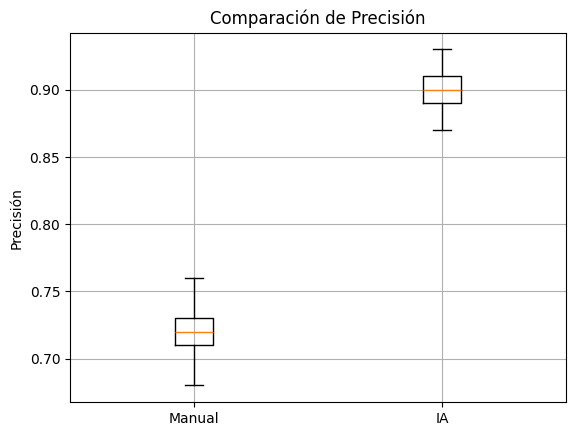

In [11]:
# Gráfico boxplot

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([manual, ia], tick_labels=["Manual", "IA"])

plt.title("Comparación de Precisión")
plt.ylabel("Precisión")

plt.grid()
plt.show()


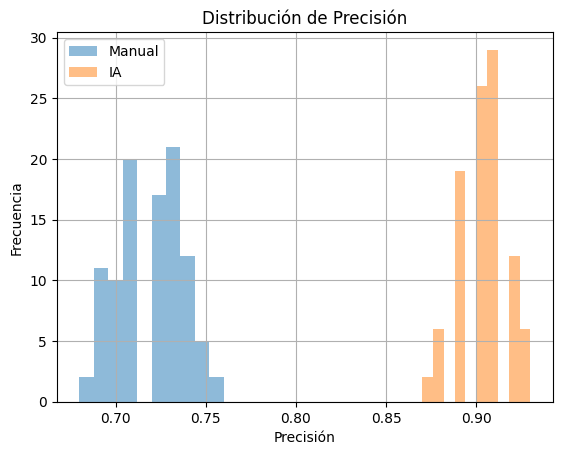

In [12]:
# Histograma

plt.figure()

plt.hist(manual, alpha=0.5, label="Manual")
plt.hist(ia, alpha=0.5, label="IA")

plt.title("Distribución de Precisión")
plt.xlabel("Precisión")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid()

plt.show()